In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score)
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

In [2]:
df = pd.read_csv('Churn_Modelling.csv')
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
df = pd.get_dummies(df, drop_first=True)

In [3]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n   Train set: {X_train.shape[0]:,} registros")
print(f"   Test set: {X_test.shape[0]:,} registros")
print(f"   Tasa de churn en train: {y_train.mean():.2%}")
print(f"   Tasa de churn en test: {y_test.mean():.2%}")


   Train set: 8,000 registros
   Test set: 2,000 registros
   Tasa de churn en train: 20.38%
   Tasa de churn en test: 20.35%


In [5]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4)

rf_model.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [7]:
rf_auc = roc_auc_score(y_test, y_prob_rf)
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print(f"Random Forest - Resultados:")
print(f"   AUC-ROC:   {rf_auc:.4f}")
print(f"   Accuracy:  {rf_acc:.4f}")
print(f"   Precision: {rf_precision:.4f}")
print(f"   Recall:    {rf_recall:.4f}")
print(f"   F1-Score:  {rf_f1:.4f}")

feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Features más importantes (Random Forest):")
print(feature_importance_rf.head(10))

Random Forest - Resultados:
   AUC-ROC:   0.8648
   Accuracy:  0.8690
   Precision: 0.8194
   Recall:    0.4570
   F1-Score:  0.5868

Top 10 Features más importantes (Random Forest):
              Feature  Importance
1                 Age    0.331577
4       NumOfProducts    0.239353
3             Balance    0.103381
6      IsActiveMember    0.070685
0         CreditScore    0.068125
7     EstimatedSalary    0.066143
8   Geography_Germany    0.052323
2              Tenure    0.034274
10        Gender_Male    0.017968
5           HasCrCard    0.008572


In [8]:
xgb_base = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False)

In [9]:
param_grid_xgb = {
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [200, 300],
    'subsample': [0.8],
    'colsample_bytree': [0.8]}

print(f"\nBuscando mejores hiperparámetros...")
print(f"Espacio de búsqueda: {np.prod([len(v) for v in param_grid_xgb.values()])} combinaciones")


Buscando mejores hiperparámetros...
Espacio de búsqueda: 8 combinaciones


In [18]:
xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print(f"Grid Search completado")
print(f"\nMejores hiperparámetros encontrados:")
for param, value in xgb_grid.best_params_.items():
    print(f"   {param}: {value}")

print(f"\nMejor AUC-ROC en validación cruzada: {xgb_grid.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits


C:\Users\alex_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:199: UserWarning: [17:18:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Grid Search completado

Mejores hiperparámetros encontrados:
   colsample_bytree: 0.8
   learning_rate: 0.05
   max_depth: 4
   n_estimators: 200
   subsample: 0.8

Mejor AUC-ROC en validación cruzada: 0.8637


In [11]:
xgb_best = xgb_grid.best_estimator_

y_pred_xgb = xgb_best.predict(X_test)
y_prob_xgb = xgb_best.predict_proba(X_test)[:, 1]

xgb_auc = roc_auc_score(y_test, y_prob_xgb)
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

print(f"XGBoost Optimizado - Resultados en Test:")
print(f"   AUC-ROC:   {xgb_auc:.4f}")
print(f"   Accuracy:  {xgb_acc:.4f}")
print(f"   Precision: {xgb_precision:.4f}")
print(f"   Recall:    {xgb_recall:.4f}")
print(f"   F1-Score:  {xgb_f1:.4f}")

feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_best.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Features más importantes (XGBoost):")
print(feature_importance_xgb.head(10))

XGBoost Optimizado - Resultados en Test:
   AUC-ROC:   0.8706
   Accuracy:  0.8695
   Precision: 0.7920
   Recall:    0.4865
   F1-Score:  0.6027

Top 10 Features más importantes (XGBoost):
              Feature  Importance
4       NumOfProducts    0.262846
1                 Age    0.195652
6      IsActiveMember    0.180187
8   Geography_Germany    0.114089
3             Balance    0.058625
10        Gender_Male    0.047623
9     Geography_Spain    0.036489
0         CreditScore    0.028888
7     EstimatedSalary    0.027560
2              Tenure    0.024079


In [12]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_data_in_leaf=20,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test)
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

lgb_auc = roc_auc_score(y_test, y_prob_lgb)
lgb_acc = accuracy_score(y_test, y_pred_lgb)
lgb_precision = precision_score(y_test, y_pred_lgb)
lgb_recall = recall_score(y_test, y_pred_lgb)
lgb_f1 = f1_score(y_test, y_pred_lgb)

print(f"LightGBM - Resultados:")
print(f"   AUC-ROC:   {lgb_auc:.4f}")
print(f"   Accuracy:  {lgb_acc:.4f}")
print(f"   Precision: {lgb_precision:.4f}")
print(f"   Recall:    {lgb_recall:.4f}")
print(f"   F1-Score:  {lgb_f1:.4f}")

LightGBM - Resultados:
   AUC-ROC:   0.8556
   Accuracy:  0.8595
   Precision: 0.7368
   Recall:    0.4816
   F1-Score:  0.5825


In [13]:
cat_model = cb.CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    verbose=0
)

cat_model.fit(X_train, y_train)

y_pred_cat = cat_model.predict(X_test)
y_prob_cat = cat_model.predict_proba(X_test)[:, 1]

cat_auc = roc_auc_score(y_test, y_prob_cat)
cat_acc = accuracy_score(y_test, y_pred_cat)
cat_precision = precision_score(y_test, y_pred_cat)
cat_recall = recall_score(y_test, y_pred_cat)
cat_f1 = f1_score(y_test, y_pred_cat)

print(f" CatBoost - Resultados:")
print(f"   AUC-ROC:   {cat_auc:.4f}")
print(f"   Accuracy:  {cat_acc:.4f}")
print(f"   Precision: {cat_precision:.4f}")
print(f"   Recall:    {cat_recall:.4f}")
print(f"   F1-Score:  {cat_f1:.4f}")


 CatBoost - Resultados:
   AUC-ROC:   0.8693
   Accuracy:  0.8715
   Precision: 0.7976
   Recall:    0.4939
   F1-Score:  0.6100


In [14]:
estimators = [
    ('xgb', xgb_best),
    ('lgb', lgb_model),
    ('cat', cat_model)
]

meta_modelo = LogisticRegression(max_iter=1000, random_state=42)

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_modelo,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1,
    passthrough=False
)

print("\nEntrenando Stacking Ensemble...")
print("   Nivel 1: XGBoost, LightGBM, CatBoost")
print("   Meta-learner: Regresión Logística")

stack_model.fit(X_train, y_train)

y_pred_stack = stack_model.predict(X_test)
y_prob_stack = stack_model.predict_proba(X_test)[:, 1]

stack_auc = roc_auc_score(y_test, y_prob_stack)
stack_acc = accuracy_score(y_test, y_pred_stack)
stack_precision = precision_score(y_test, y_pred_stack)
stack_recall = recall_score(y_test, y_pred_stack)
stack_f1 = f1_score(y_test, y_pred_stack)

print(f"Stacking Ensemble - Resultados:")
print(f"   AUC-ROC:   {stack_auc:.4f}")
print(f"   Accuracy:  {stack_acc:.4f}")
print(f"   Precision: {stack_precision:.4f}")
print(f"   Recall:    {stack_recall:.4f}")
print(f"   F1-Score:  {stack_f1:.4f}")



Entrenando Stacking Ensemble...
   Nivel 1: XGBoost, LightGBM, CatBoost
   Meta-learner: Regresión Logística
Stacking Ensemble - Resultados:
   AUC-ROC:   0.8702
   Accuracy:  0.8680
   Precision: 0.7804
   Recall:    0.4889
   F1-Score:  0.6012


In [15]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Stacking'],
    'AUC-ROC': [rf_auc, xgb_auc, lgb_auc, cat_auc, stack_auc],
    'Accuracy': [rf_acc, xgb_acc, lgb_acc, cat_acc, stack_acc],
    'Precision': [rf_precision, xgb_precision, lgb_precision, cat_precision, stack_precision],
    'Recall': [rf_recall, xgb_recall, lgb_recall, cat_recall, stack_recall],
    'F1-Score': [rf_f1, xgb_f1, lgb_f1, cat_f1, stack_f1]
})

results = results.sort_values('AUC-ROC', ascending=False)

print("TABLA COMPARATIVA DE RESULTADOS:")
print(results.to_string(index=False))

best_model_name = results.iloc[0]['Model']
best_auc = results.iloc[0]['AUC-ROC']

print(f"\nMEJOR MODELO: {best_model_name}")
print(f"AUC-ROC: {best_auc:.4f}")

TABLA COMPARATIVA DE RESULTADOS:
        Model  AUC-ROC  Accuracy  Precision   Recall  F1-Score
      XGBoost 0.870579    0.8695   0.792000 0.486486  0.602740
     Stacking 0.870211    0.8680   0.780392 0.488943  0.601208
     CatBoost 0.869313    0.8715   0.797619 0.493857  0.610015
Random Forest 0.864846    0.8690   0.819383 0.457002  0.586751
     LightGBM 0.855550    0.8595   0.736842 0.481572  0.582467

MEJOR MODELO: XGBoost
AUC-ROC: 0.8706


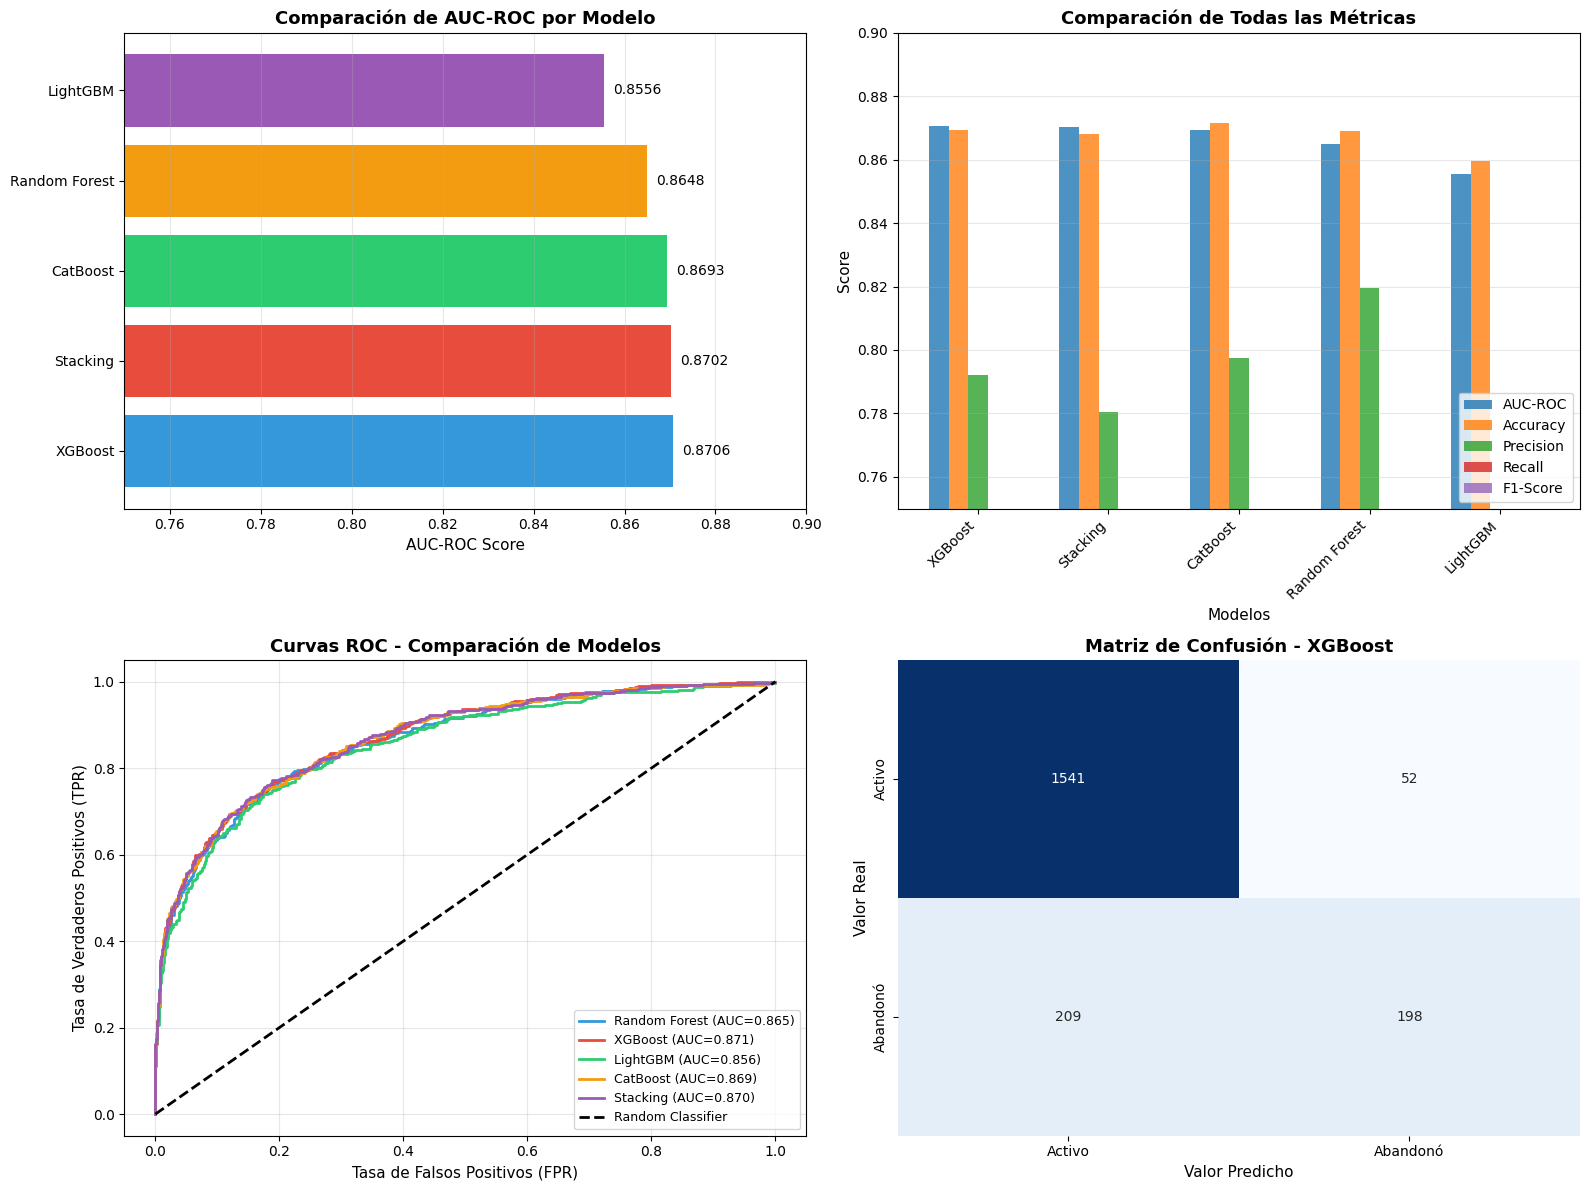

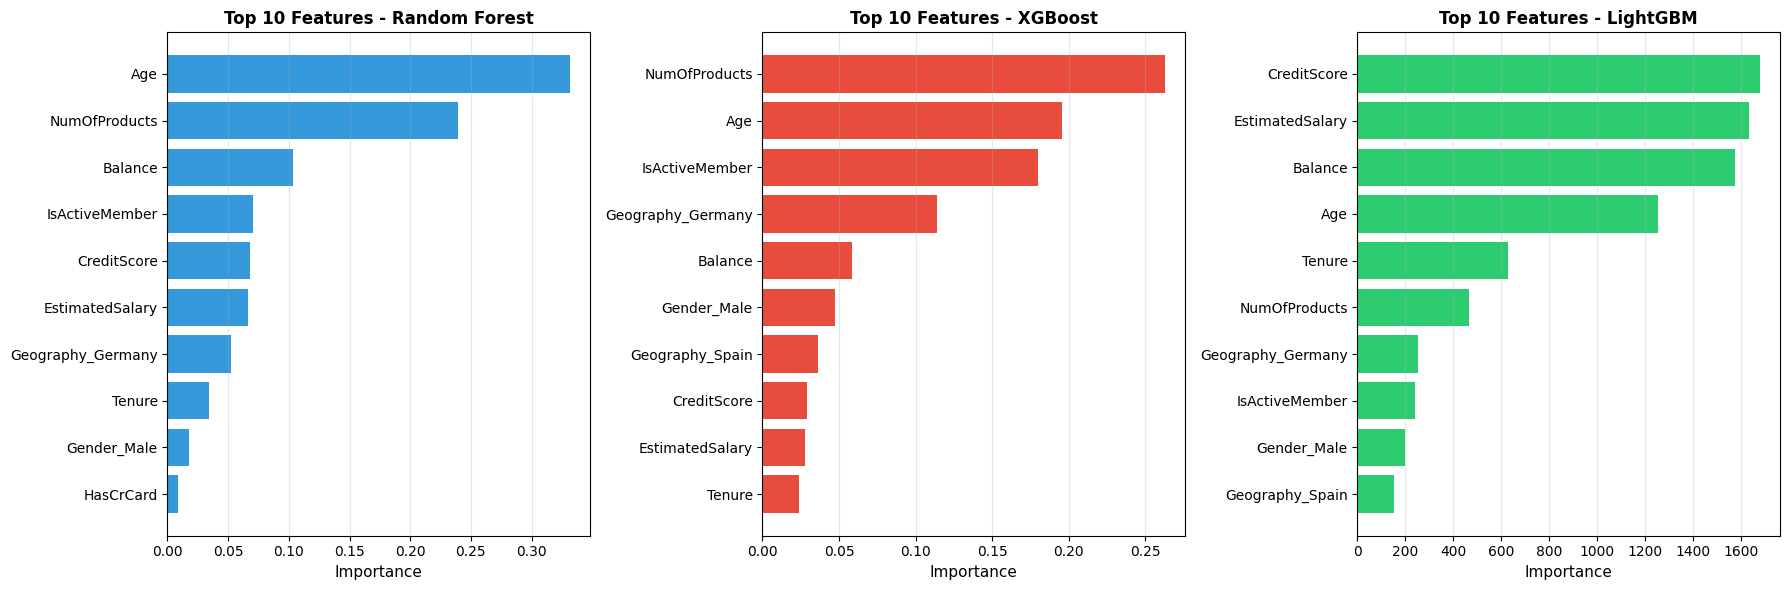

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0, 0]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
bars = ax1.barh(results['Model'], results['AUC-ROC'], color=colors)
ax1.set_xlabel('AUC-ROC Score', fontsize=11)
ax1.set_title('Comparación de AUC-ROC por Modelo', fontsize=13, fontweight='bold')
ax1.set_xlim([0.75, 0.90])
for i, (bar, val) in enumerate(zip(bars, results['AUC-ROC'])):
    ax1.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
             va='center', fontsize=10)
ax1.grid(axis='x', alpha=0.3)

ax2 = axes[0, 1]
metrics = ['AUC-ROC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results))
width = 0.15

for i, metric in enumerate(metrics):
    offset = width * (i - 2)
    ax2.bar(x + offset, results[metric], width, label=metric, alpha=0.8)

ax2.set_xlabel('Modelos', fontsize=11)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('Comparación de Todas las Métricas', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(results['Model'], rotation=45, ha='right')
ax2.legend(loc='lower right')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0.75, 0.90])

ax3 = axes[1, 0]

models_roc = [
    ('Random Forest', y_prob_rf, '#3498db'),
    ('XGBoost', y_prob_xgb, '#e74c3c'),
    ('LightGBM', y_prob_lgb, '#2ecc71'),
    ('CatBoost', y_prob_cat, '#f39c12'),
    ('Stacking', y_prob_stack, '#9b59b6')
]

for name, y_prob, color in models_roc:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    ax3.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})', color=color, lw=2)

ax3.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
ax3.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax3.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax3.set_title('Curvas ROC - Comparación de Modelos', fontsize=13, fontweight='bold')
ax3.legend(loc='lower right', fontsize=9)
ax3.grid(alpha=0.3)

ax4 = axes[1, 1]
if best_model_name == 'Stacking':
    cm = confusion_matrix(y_test, y_pred_stack)
elif best_model_name == 'XGBoost':
    cm = confusion_matrix(y_test, y_pred_xgb)
elif best_model_name == 'LightGBM':
    cm = confusion_matrix(y_test, y_pred_lgb)
elif best_model_name == 'CatBoost':
    cm = confusion_matrix(y_test, y_pred_cat)
else:
    cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax4,
            xticklabels=['Activo', 'Abandonó'],
            yticklabels=['Activo', 'Abandonó'])
ax4.set_title(f'Matriz de Confusión - {best_model_name}', fontsize=13, fontweight='bold')
ax4.set_ylabel('Valor Real', fontsize=11)
ax4.set_xlabel('Valor Predicho', fontsize=11)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

top_rf = feature_importance_rf.head(10)
axes[0].barh(range(len(top_rf)), top_rf['Importance'], color='#3498db')
axes[0].set_yticks(range(len(top_rf)))
axes[0].set_yticklabels(top_rf['Feature'])
axes[0].set_xlabel('Importance', fontsize=11)
axes[0].set_title('Top 10 Features - Random Forest', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

top_xgb = feature_importance_xgb.head(10)
axes[1].barh(range(len(top_xgb)), top_xgb['Importance'], color='#e74c3c')
axes[1].set_yticks(range(len(top_xgb)))
axes[1].set_yticklabels(top_xgb['Feature'])
axes[1].set_xlabel('Importance', fontsize=11)
axes[1].set_title('Top 10 Features - XGBoost', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

feature_importance_lgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lgb_model.feature_importances_
}).sort_values('Importance', ascending=False)
top_lgb = feature_importance_lgb.head(10)
axes[2].barh(range(len(top_lgb)), top_lgb['Importance'], color='#2ecc71')
axes[2].set_yticks(range(len(top_lgb)))
axes[2].set_yticklabels(top_lgb['Feature'])
axes[2].set_xlabel('Importance', fontsize=11)
axes[2].set_title('Top 10 Features - LightGBM', fontsize=12, fontweight='bold')
axes[2].invert_yaxis()
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


In [17]:
print(f"MEJORAS RESPECTO AL BASELINE:")
print(f"   Regresión Logística tuvo un AUC-ROC de 0.775")
print(f"   Mejor modelo actual ({best_model_name}): AUC-ROC = {best_auc:.4f}")

print(f"\nINTERPRETACIÓN DE RESULTADOS:")
print(f"   - Los modelos de Gradient Boosting superan a Random Forest")
print(f"   - XGBoost optimizado muestra excelente desempeño")
print(f"   - Stacking combina fortalezas de múltiples modelos pero no supera a XGBoost")

print(f"\nRECOMENDACIONES:")
print(f"   1. Implementar {best_model_name} en producción")
print(f"   2. Monitorear métricas de negocio")
print(f"   3. Realizar re-entrenamiento periódico con nuevos datos")

MEJORAS RESPECTO AL BASELINE:
   Regresión Logística tuvo un AUC-ROC de 0.775
   Mejor modelo actual (XGBoost): AUC-ROC = 0.8706

INTERPRETACIÓN DE RESULTADOS:
   - Los modelos de Gradient Boosting superan a Random Forest
   - XGBoost optimizado muestra excelente desempeño
   - Stacking combina fortalezas de múltiples modelos pero no supera a XGBoost

RECOMENDACIONES:
   1. Implementar XGBoost en producción
   2. Monitorear métricas de negocio
   3. Realizar re-entrenamiento periódico con nuevos datos
